# cifar-10 dataset으로 이미지 분류 모델 - CNN을 사용하지 않기
총 10개의 레이블과 6만장의 칼라 이미지(32 * 32).
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck 

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

In [28]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('샘플 수: ', x_train.shape)       # (50000, 32, 32, 3)
print('채널 수: ', x_train.shape[3])
print('이미지 크기: ', x_train.shape[1], x_train.shape[2])
print('test 샘플 수: ', x_test.shape) 
print('test type: ', x_test.dtype)
# print(x_train[0])
print(y_train[0])


샘플 수:  (50000, 32, 32, 3)
채널 수:  3
이미지 크기:  32 32
test 샘플 수:  (10000, 32, 32, 3)
test type:  uint8
[6]


# 시각화

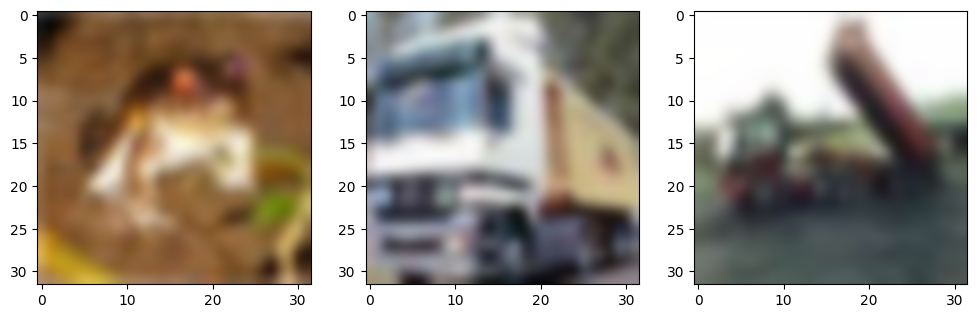

In [29]:
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(x_train[0], interpolation='bicubic')
plt.subplot(132)
plt.imshow(x_train[1], interpolation='bicubic')
plt.subplot(133)
plt.imshow(x_train[2], interpolation='bicubic')
plt.show()

# feature 정규화

In [30]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# print(x_train[0])

# label(class) 원핫 처리
NUM_CLASSES = 10
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)
# print(y_train[0])

# model 만들기

In [31]:
from matplotlib import units

'''
model = Sequential([
    Input(shape=(32, 32, 3)),
    FLatten(),
    Dense(units=256, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=NUM_CLASSES, activation='softmax'),
])
print(model.summary())
'''

input_layer = Input(shape=(32, 32, 3))
x = Flatten()(input_layer)
x = Dense(units=256, activation='relu')(x)
x = Dense(units=128, activation='relu')(x)

output_layer = Dense(units=NUM_CLASSES, activation='softmax')(x)
model = Model(input_layer, output_layer)
print(model.summary())

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 flatten_2 (Flatten)         (None, 3072)              0         
                                                                 
 dense_9 (Dense)             (None, 256)               786688    
                                                                 
 dense_10 (Dense)            (None, 128)               32896     
                                                                 
 dense_11 (Dense)            (None, 10)                1290      
                                                                 
Total params: 820,874
Trainable params: 820,874
Non-trainable params: 0
_________________________________________________________________
None


In [32]:
# train
from random import shuffle
from tabnanny import verbose
from sklearn import metrics


opt = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

model.fit(x_train, y_train, batch_size=64, epochs=20, shuffle=True, verbose=2)

print('test acc: %.4f'%(model.evaluate(x_test, y_test, verbose=0, batch_size=64)[1]))
print('test loss: %.4f'%(model.evaluate(x_test, y_test, verbose=0, batch_size=64)[0]))

CLASSES = np.array(["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", 'horse', 'ship', 'truck'])

Epoch 1/20
782/782 - 1s - loss: 1.8775 - accuracy: 0.3221 - 1s/epoch - 2ms/step
Epoch 2/20
782/782 - 1s - loss: 1.6829 - accuracy: 0.3962 - 1s/epoch - 1ms/step
Epoch 3/20
782/782 - 1s - loss: 1.5981 - accuracy: 0.4301 - 1s/epoch - 1ms/step
Epoch 4/20
782/782 - 1s - loss: 1.5462 - accuracy: 0.4451 - 1s/epoch - 1ms/step
Epoch 5/20
782/782 - 1s - loss: 1.5075 - accuracy: 0.4619 - 1s/epoch - 1ms/step
Epoch 6/20
782/782 - 1s - loss: 1.4748 - accuracy: 0.4729 - 1s/epoch - 1ms/step
Epoch 7/20
782/782 - 1s - loss: 1.4444 - accuracy: 0.4846 - 1s/epoch - 2ms/step
Epoch 8/20
782/782 - 1s - loss: 1.4219 - accuracy: 0.4914 - 1s/epoch - 1ms/step
Epoch 9/20
782/782 - 1s - loss: 1.4055 - accuracy: 0.4984 - 1s/epoch - 1ms/step
Epoch 10/20
782/782 - 1s - loss: 1.3836 - accuracy: 0.5052 - 1s/epoch - 1ms/step
Epoch 11/20
782/782 - 1s - loss: 1.3610 - accuracy: 0.5149 - 1s/epoch - 1ms/step
Epoch 12/20
782/782 - 1s - loss: 1.3526 - accuracy: 0.5166 - 1s/epoch - 1ms/step
Epoch 13/20
782/782 - 1s - loss: 1.33

# pred

1/1 [==============================] - 0s 18ms/step
[3 8 8 8 4 3 3 6 2 1]
예측값:  ['cat' 'ship' 'ship' 'ship' 'deer' 'cat' 'cat' 'frog' 'bird' 'automobile']
실제값:  ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수:  5


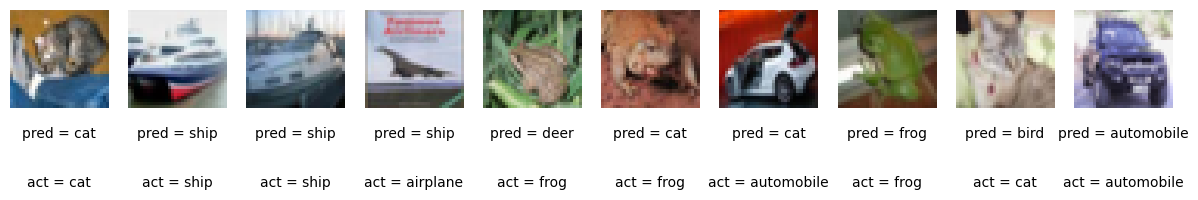

In [37]:
# pred
pred = model.predict(x_test[:10])
print(np.argmax(pred, axis=1))
pred_cla = CLASSES[np.argmax(pred, axis=-1)]
actual_cla = CLASSES[np.argmax(y_test[:10], axis=-1)]
print('예측값: ',pred_cla)
print('실제값: ',actual_cla)
print('분류 실패 수: ',(pred_cla != actual_cla).sum())

fig = plt.figure(figsize=(15,3))
for i ,idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1,len(x_test[:10]), i+1)
    ax.axis('off')
    ax.text(0.5, -0.3, 'pred = ' + str(pred_cla[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.8, 'act = ' + str(actual_cla[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.imshow(img)
plt.show()